# ECS 172 — Assignment 2: Collaborative Filtering

By: Andrew Kuang

We have user–movie ratings between 1-5 (intgers) and our goal is to to predict the
rating each user gave each movie in `test_pairs.csv`. We will then score our submissions by
RMSE against a hidden ground truth, with predictions clipped to [1, 5].

In this notebook we:

1. Explore: Data exploration (rating, user-activity, item-popularity, timestamps)
2. Split: A **per-user temporal leave-last-20%** validation data split
3. Baseline: Our baseline method: **Global-mean**
4. Improve: And expanded method: **Method 2 — Funk SVD** (matrix factorisation with biases, implemented using SGD)
5. Validate: Validation-RMSE comparison and error analysis
6. Retrain: Final retraining on the full training set so that we can write `submission.csv`.

## 1. Setup and data loading

In [1]:
from __future__ import annotations

import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from evaluation_code import rmse

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
RNG_SEED = 172
rng = np.random.default_rng(RNG_SEED)
TRAIN_PATH = "train.csv"
TEST_PAIRS_PATH = "test_pairs.csv"
MOVIES_PATH = "movies.csv"
USERS_PATH = "users.csv"
SUBMISSION_PATH = "submission.csv"
RATING_MIN, RATING_MAX = 1.0, 5.0

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_pairs_df = pd.read_csv(TEST_PAIRS_PATH)
movies_df = pd.read_csv(MOVIES_PATH)
users_df = pd.read_csv(USERS_PATH)

print(f"train.csv:       {len(train_df):>8,} rows  cols={list(train_df.columns)}")
print(f"test_pairs.csv:  {len(test_pairs_df):>8,} rows  cols={list(test_pairs_df.columns)}")
print(f"movies.csv:      {len(movies_df):>8,} rows  cols={list(movies_df.columns)}")
print(f"users.csv:       {len(users_df):>8,} rows  cols={list(users_df.columns)}")

print(f"\nglobal mean rating (train): {train_df['rating'].mean():.4f}")
print(f"distinct users in train:    {train_df['user_id'].nunique():,}")
print(f"distinct items in train:    {train_df['item_id'].nunique():,}")

train_items = set(train_df["item_id"].unique())
cold_items_in_test = test_pairs_df.loc[~test_pairs_df["item_id"].isin(train_items), "item_id"].unique()

# cold start items appear in the test site but were never rated in train...not good
print(f"cold-start items in test:   {len(cold_items_in_test):,}")

train_df.head()

train.csv:        797,758 rows  cols=['user_id', 'item_id', 'rating', 'timestamp']
test_pairs.csv:   202,451 rows  cols=['user_id', 'item_id']
movies.csv:         3,883 rows  cols=['item_id', 'title', 'year', 'genres']
users.csv:          6,040 rows  cols=['user_id', 'gender', 'age_group', 'occupation']

global mean rating (train): 3.6168
distinct users in train:    6,040
distinct items in train:    3,666
cold-start items in test:   40


,user_id,item_id,rating,timestamp
0,1,3186,4,978300019
1,1,1721,4,978300055
2,1,1270,5,978300055
3,1,1022,5,978300055
4,1,2340,3,978300103


## 2. Data exploration

Our goal here is to see four things:
1. Rating distribution and especially category (label) balance
2. User-activity distribution to see how skewed user contributions are
3. Item-popularity distribution (skewed item exposure)
4. Timestamp range (**see if the time-based split will shift test ratings**)

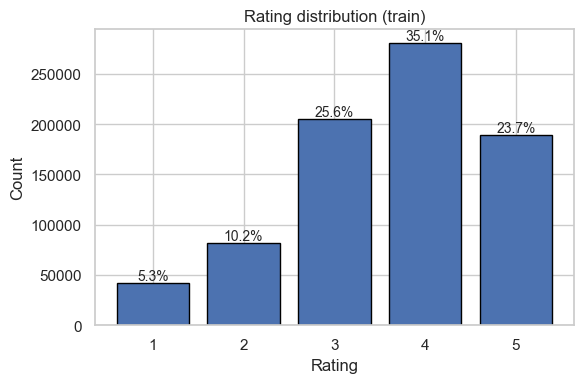

mean rating:   3.6168
median rating: 4
std:           1.1103


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train_df["rating"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="black")
# add text with the rating number
for r, c in counts.items():
    ax.text(r, c, f"{c/len(train_df):.1%}", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Rating distribution (train)")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# brief summary
print(f"mean rating:   {train_df['rating'].mean():.4f}")
print(f"median rating: {train_df['rating'].median():.0f}")
print(f"std:           {train_df['rating'].std():.4f}")

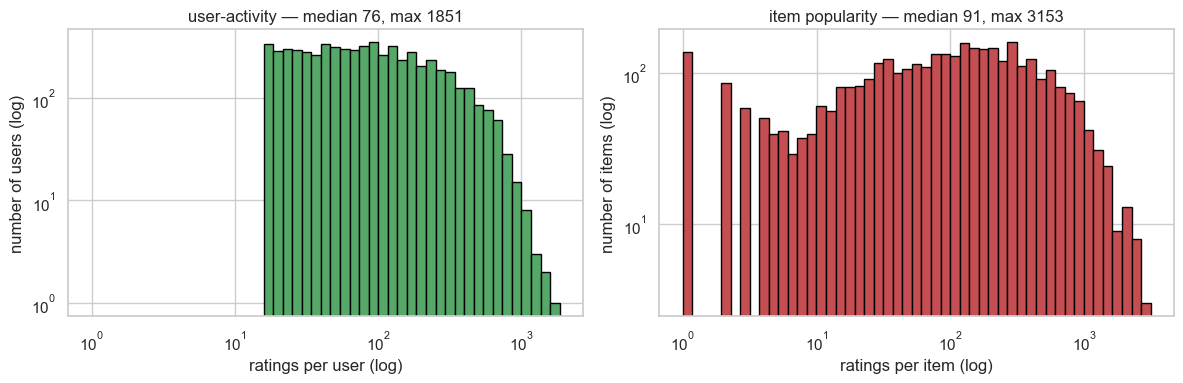

user-activity quantiles (ratings per user):
0.10     21.0
0.25     35.0
0.50     76.0
0.75    166.0
0.90    320.0
0.99    725.0

item-popularity quantiles (ratings per item):
0.10       5.0
0.25      24.0
0.50      92.0
0.75     271.0
0.90     586.0
0.99    1532.0

items with <5 train ratings: 329 of 3,666


In [5]:
# counts of users and items - for histogram sizing
user_counts = train_df.groupby("user_id").size()
item_counts = train_df.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# visualize number of ratings per user
axes[0].hist(user_counts.values, bins=np.logspace(0, np.log10(user_counts.max()), 50), color="#55A868", edgecolor="black")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("ratings per user (log)")
axes[0].set_ylabel("number of users (log)")
axes[0].set_title(f"user-activity — median {int(user_counts.median())}, max {int(user_counts.max())}")

# see item popularity
axes[1].hist(item_counts.values, bins=np.logspace(0, np.log10(item_counts.max()), 50), color="#C44E52", edgecolor="black")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("ratings per item (log)")
axes[1].set_ylabel("number of items (log)")
axes[1].set_title(f"item popularity — median {int(item_counts.median())}, max {int(item_counts.max())}")

plt.tight_layout()
plt.show()

print("user-activity quantiles (ratings per user):")
print(user_counts.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(0).to_string())
print("\nitem-popularity quantiles (ratings per item):")
print(item_counts.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(0).to_string())
print(f"\nitems with <5 train ratings: {(item_counts < 5).sum():,} of {len(item_counts):,}")

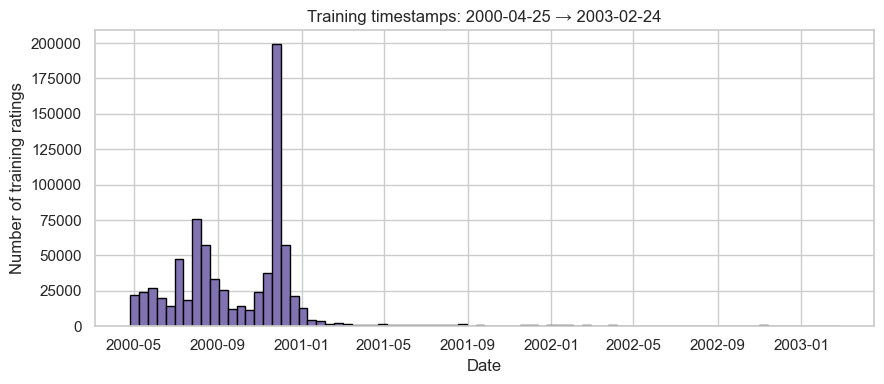

per-user, the held-out test slice is the most recent ceil(0.20 * n) ratings.
for our validation split we will mimic this on train.csv with a 20% slice.
mean held-out fraction across users: 0.208


In [6]:
train_dt = pd.to_datetime(train_df["timestamp"], unit="s")
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_dt, bins=80, color="#8172B2", edgecolor="black")
ax.set_xlabel("Date")
ax.set_ylabel("Number of training ratings")
ax.set_title(f"Training timestamps: {train_dt.min().date()} → {train_dt.max().date()}")
plt.tight_layout()
plt.show()

# here I want to see what fraction of ratings come in the last 20% of their timeline?
def per_user_last_window_share(group: pd.DataFrame, frac: float = 0.20) -> float:
    n = len(group)
    k = max(1, math.ceil(frac * n))
    return k / n

share = train_df.groupby("user_id").apply(per_user_last_window_share, include_groups=False)
print(f"per-user, the held-out test slice is the most recent ceil(0.20 * n) ratings.")
print(f"for our validation split we will mimic this on train.csv with a 20% slice.")

print(f"mean held-out fraction across users: {share.mean():.3f}")

## 3. Validation split — per-user temporal leave-last-20%

Our TAs will build a test set by sorting each user's ratings by timestamp and
holding out the most recent `ceil(0.20 * n)` ratings. 

So to make our validation RMSE track the leaderboard, we apply the same procedure to `train.csv`:

1. Sort each user's ratings by `(timestamp, item_id)`
2. The most-recent 20% becomes the validation fold; the rest is for training
3. Every user keeps at least one rating in each fold (ok because every user has more than 5 ratings in `train.csv`).

`train_inner` is what we fit candidate models on, `val_df` is what we score them against.

In [7]:
def per_user_temporal_split(df: pd.DataFrame, frac: float = 0.20) -> tuple[pd.DataFrame, pd.DataFrame]:
    """hold out the most recent ceil(frac * n) ratings per user."""
    sorted_df = df.sort_values(["user_id", "timestamp", "item_id"], kind="mergesort").reset_index(drop=True)
    n_per_user = sorted_df.groupby("user_id")["rating"].transform("size")
    rank_in_user = sorted_df.groupby("user_id").cumcount()  # 0-indexed, ascending in time
    n_val_per_user = np.ceil(frac * n_per_user).astype(int)
    is_val = rank_in_user >= (n_per_user - n_val_per_user)
    return sorted_df.loc[~is_val].reset_index(drop=True), sorted_df.loc[is_val].reset_index(drop=True)

train_inner, val_df = per_user_temporal_split(train_df, frac=0.20)

print(f"train_inner: {len(train_inner):>8,} rows")
print(f"val_df:      {len(val_df):>8,} rows  ({len(val_df)/len(train_df):.1%} of train)")
print(f"users in both folds: train={train_inner['user_id'].nunique():,}, val={val_df['user_id'].nunique():,}")

train_inner_items = set(train_inner["item_id"].unique())
cold_items_val = val_df.loc[~val_df["item_id"].isin(train_inner_items), "item_id"].unique()
print(f"Cold-start items in val (not in train_inner): {len(cold_items_val):,}")
print(f"  (test set has {len(cold_items_in_test)} cold-start items, so the validation fold "
      f"shows a similar regime.)")

train_inner:  635,723 rows
val_df:       162,035 rows  (20.3% of train)
users in both folds: train=6,040, val=6,040
Cold-start items in val (not in train_inner): 31
  (test set has 40 cold-start items, so the validation fold shows a similar regime.)


## 4. Method 1 — global-mean baseline

The simplest collaborative-filtering baseline is predicting the training-set global mean for every (user, item) pair. This will give us a reference RMSE to beat.

In [8]:
def predict_global_mean(train: pd.DataFrame, pairs: pd.DataFrame) -> pd.DataFrame:
    mu = float(train["rating"].mean())
    out = pairs[["user_id", "item_id"]].copy()
    out["predicted_rating"] = np.clip(mu, RATING_MIN, RATING_MAX)
    return out

global_mean_val_pred = predict_global_mean(train_inner, val_df)
global_mean_val_rmse = rmse(val_df[["user_id", "item_id", "rating"]], global_mean_val_pred)
print(f"global-mean baseline — validation RMSE: {global_mean_val_rmse:.4f}")
print(f"  (mu used: {train_inner['rating'].mean():.4f})")

global-mean baseline — validation RMSE: 1.1199
  (mu used: 3.6442)


This is fairly expected, as hinted by some small calculations on the test rating histogram in `split_stats.json`

## 5. Method 2 — Funk SVD (matrix factorisation with biases)

We model each rating as a global mean, plus user/item bias terms, plus a
dot product between learned latent vectors. Then, we will optimise with stochastic gradient descent. 

Some **hyperparameters** we will tune on the validation fold are the latent dimension $K$, learning rate $\eta$, regularisation $\lambda$, and number of epochs.

In [ ]:
class FunkSVD:
    def __init__(self, n_factors: int = 20, lr: float = 0.005, reg: float = 0.05,
                 n_epochs: int = 20, init_std: float = 0.1, random_state: int = RNG_SEED):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.init_std = init_std
        self.random_state = random_state

    def _index(self, train: pd.DataFrame) -> None:
        self.user_ids_ = np.sort(train["user_id"].unique())
        self.item_ids_ = np.sort(train["item_id"].unique())
        # map users to ids
        self.user_to_idx_ = {u: i for i, u in enumerate(self.user_ids_)}
        # map items to ids
        self.item_to_idx_ = {it: i for i, it in enumerate(self.item_ids_)}
        self.n_users_ = len(self.user_ids_)
        self.n_items_ = len(self.item_ids_)

    def fit(self, train: pd.DataFrame, val: pd.DataFrame | None = None,
            verbose: bool = True) -> "FunkSVD":
        self._index(train)
        u_arr = train["user_id"].map(self.user_to_idx_).to_numpy(dtype=np.int32)
        i_arr = train["item_id"].map(self.item_to_idx_).to_numpy(dtype=np.int32)
        r_arr = train["rating"].to_numpy(dtype=np.float64)

        rng = np.random.default_rng(self.random_state)
        self.mu_ = float(r_arr.mean())
        self.bu_ = np.zeros(self.n_users_, dtype=np.float64)
        self.bi_ = np.zeros(self.n_items_, dtype=np.float64)
        self.P_ = rng.normal(0.0, self.init_std, size=(self.n_users_, self.n_factors))
        self.Q_ = rng.normal(0.0, self.init_std, size=(self.n_items_, self.n_factors))

        N = len(r_arr)
        history: list[dict] = []

        for epoch in range(1, self.n_epochs + 1):
            t0 = time.time()
            perm = rng.permutation(N)
            self._sgd_epoch(perm, u_arr, i_arr, r_arr)
            train_rmse = self._rmse_arrays(u_arr, i_arr, r_arr)
            row = {"epoch": epoch, "train_rmse": train_rmse, "secs": time.time() - t0}
            if val is not None:
                val_pred = self.predict(val)
                row["val_rmse"] = rmse(val[["user_id", "item_id", "rating"]], val_pred)
            history.append(row)
            # logging the epochs - this should be turned on during development
            if verbose:
                msg = f"epoch {epoch:>2}/{self.n_epochs}  train={train_rmse:.4f}"
                if "val_rmse" in row:
                    msg += f"  val={row['val_rmse']:.4f}"
                msg += f"  ({row['secs']:.1f}s)"
                print(msg)

        self.history_ = pd.DataFrame(history)
        return self

    def _sgd_epoch(self, perm: np.ndarray, u_arr: np.ndarray,
                   i_arr: np.ndarray, r_arr: np.ndarray) -> None:
        # we bind to locals to improve performance
        mu, bu, bi, P, Q = self.mu_, self.bu_, self.bi_, self.P_, self.Q_
        lr, reg = self.lr, self.reg
        for idx in perm:
            u = u_arr[idx]
            i = i_arr[idx]
            r = r_arr[idx]
            p_u = P[u]
            q_i = Q[i]
            # calculate error
            err = r - mu - bu[u] - bi[i] - p_u @ q_i
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            p_old = p_u.copy()
            P[u] = p_u + lr * (err * q_i - reg * p_u)
            Q[i] = q_i + lr * (err * p_old - reg * q_i)

    def _rmse_arrays(self, u_arr: np.ndarray, i_arr: np.ndarray, r_arr: np.ndarray) -> float:
        pred = (self.mu_
                + self.bu_[u_arr]
                + self.bi_[i_arr]
                + np.einsum("ij,ij->i", self.P_[u_arr], self.Q_[i_arr]))
        
        # we need to clip our ratings to the min/max from our dataset
        pred = np.clip(pred, RATING_MIN, RATING_MAX)
        return float(np.sqrt(np.mean((pred - r_arr) ** 2)))

    def predict(self, pairs: pd.DataFrame) -> pd.DataFrame:
        u_series = pairs["user_id"].map(self.user_to_idx_)
        i_series = pairs["item_id"].map(self.item_to_idx_)
        u_known = u_series.notna().to_numpy()
        i_known = i_series.notna().to_numpy()
        u_idx = u_series.fillna(0).astype(np.int64).to_numpy()
        i_idx = i_series.fillna(0).astype(np.int64).to_numpy()

        bu_part = np.where(u_known, self.bu_[u_idx], 0.0)
        bi_part = np.where(i_known, self.bi_[i_idx], 0.0)
        both = u_known & i_known
        pq_part = np.where(both, np.einsum("ij,ij->i", self.P_[u_idx], self.Q_[i_idx]), 0.0)
        pred = np.clip(self.mu_ + bu_part + bi_part + pq_part, RATING_MIN, RATING_MAX)

        out = pairs[["user_id", "item_id"]].copy()
        out["predicted_rating"] = pred
        return out

### 5.1 Single training run

We start with some sensible default values of: $K=20$, $\eta=0.005$, $\lambda=0.05$,
20 epochs. 

Then, we will watch train/validation RMSE per epoch to make sure we are 
not over-fitting before the final epoch. 

In [10]:
funk = FunkSVD(n_factors=20, lr=0.005, reg=0.05, n_epochs=20, random_state=RNG_SEED)
funk.fit(train_inner, val=val_df, verbose=True)

epoch  1/20  train=0.9414  val=0.9613  (4.4s)
epoch  2/20  train=0.9190  val=0.9372  (4.3s)
epoch  3/20  train=0.9094  val=0.9280  (4.3s)
epoch  4/20  train=0.9039  val=0.9230  (4.2s)
epoch  5/20  train=0.9002  val=0.9200  (4.1s)
epoch  6/20  train=0.8975  val=0.9179  (4.1s)
epoch  7/20  train=0.8952  val=0.9163  (4.2s)
epoch  8/20  train=0.8930  val=0.9155  (4.1s)
epoch  9/20  train=0.8907  val=0.9139  (4.1s)
epoch 10/20  train=0.8882  val=0.9128  (4.1s)
epoch 11/20  train=0.8853  val=0.9113  (4.1s)
epoch 12/20  train=0.8821  val=0.9094  (4.1s)
epoch 13/20  train=0.8783  val=0.9073  (4.1s)
epoch 14/20  train=0.8744  val=0.9051  (4.1s)
epoch 15/20  train=0.8705  val=0.9035  (4.2s)
epoch 16/20  train=0.8666  val=0.9011  (4.2s)
epoch 17/20  train=0.8628  val=0.8997  (4.2s)
epoch 18/20  train=0.8590  val=0.8976  (4.2s)
epoch 19/20  train=0.8551  val=0.8958  (4.2s)
epoch 20/20  train=0.8513  val=0.8941  (4.2s)


RSME drops and it looks like validation RSME falls down slightly following the training one

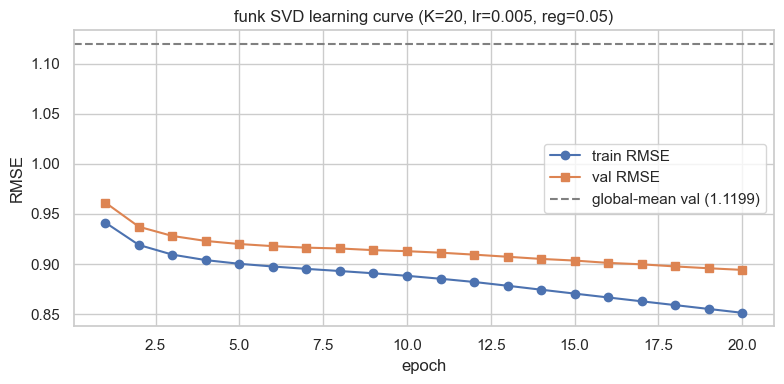

best validation RMSE: 0.8941 at epoch 20


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(funk.history_["epoch"], funk.history_["train_rmse"], marker="o", label="train RMSE")
ax.plot(funk.history_["epoch"], funk.history_["val_rmse"], marker="s", label="val RMSE")
ax.axhline(global_mean_val_rmse, color="grey", linestyle="--", label=f"global-mean val ({global_mean_val_rmse:.4f})")
ax.set_xlabel("epoch")
ax.set_ylabel("RMSE")
ax.set_title(f"funk SVD learning curve (K={funk.n_factors}, lr={funk.lr}, reg={funk.reg})")
ax.legend()
plt.tight_layout()
plt.show()

best_epoch = int(funk.history_["val_rmse"].idxmin()) + 1
best_val = float(funk.history_["val_rmse"].min())
print(f"best validation RMSE: {best_val:.4f} at epoch {best_epoch}")

### 5.2 Testing many hyperparameters

I now want to just try out the latent dimension $K$ and the regularisation strength $\lambda$
on the same train / val split. Higher $K$ can be prone to over-fitting; higher $\lambda$ pulls parameters toward zero
(so the model trusts global mean more).

In [12]:
sweep_grid = [
    {"n_factors": 10, "reg": 0.05},
    {"n_factors": 20, "reg": 0.05},
    {"n_factors": 50, "reg": 0.05},
    {"n_factors": 20, "reg": 0.02},
    {"n_factors": 20, "reg": 0.10},
]
sweep_results = []
for cfg in sweep_grid:
    print(f"\n=== K={cfg['n_factors']}, reg={cfg['reg']} ===")
    m = FunkSVD(n_factors=cfg["n_factors"], lr=0.005, reg=cfg["reg"],
                n_epochs=15, random_state=RNG_SEED).fit(train_inner, val=val_df, verbose=False)
    best_idx = m.history_["val_rmse"].idxmin()
    sweep_results.append({
        "K": cfg["n_factors"],
        "reg": cfg["reg"],
        "best_epoch": int(m.history_.loc[best_idx, "epoch"]),
        "best_val_rmse": float(m.history_.loc[best_idx, "val_rmse"]),
        "final_train_rmse": float(m.history_["train_rmse"].iloc[-1]),
    })
    print(f"  best val RMSE = {sweep_results[-1]['best_val_rmse']:.4f} "
          f"at epoch {sweep_results[-1]['best_epoch']}")

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_rmse").reset_index(drop=True)
sweep_df


=== K=10, reg=0.05 ===
  best val RMSE = 0.9081 at epoch 15

=== K=20, reg=0.05 ===
  best val RMSE = 0.9035 at epoch 15

=== K=50, reg=0.05 ===
  best val RMSE = 0.9015 at epoch 15

=== K=20, reg=0.02 ===
  best val RMSE = 0.8976 at epoch 15

=== K=20, reg=0.1 ===
  best val RMSE = 0.9135 at epoch 15


,K,reg,best_epoch,best_val_rmse,final_train_rmse
0,20,0.02,15,0.897637,0.840888
1,50,0.05,15,0.901475,0.852440
2,20,0.05,15,0.903466,0.870472
3,10,0.05,15,0.908126,0.883252
4,20,0.10,15,0.913497,0.893148


## 6. Validation RMSE comparison and error analysis

We compare the global-mean baseline against the best Funk-SVD configuration
on identical validation predictions. Then, it would be good to split the Funk-SVD error down
along cold-start items, low-activity users, low-popularity items, and extreme ratings.

In [13]:
# pick the best sweep config for the rest of the analysis
best_cfg = sweep_df.iloc[0].to_dict()
print(f"Best config: K={int(best_cfg['K'])}, reg={best_cfg['reg']}, epoch={int(best_cfg['best_epoch'])}")

best_funk = FunkSVD(
    n_factors=int(best_cfg["K"]),
    lr=0.005,
    reg=float(best_cfg["reg"]),
    n_epochs=int(best_cfg["best_epoch"]),
    random_state=RNG_SEED,
).fit(train_inner, val=val_df, verbose=False)

best_funk_val_pred = best_funk.predict(val_df)
best_funk_val_rmse = rmse(val_df[["user_id", "item_id", "rating"]], best_funk_val_pred)

results_table = pd.DataFrame([
    {"method": "Global-mean baseline", "val_rmse": global_mean_val_rmse},
    {"method": f"Funk SVD (K={int(best_cfg['K'])}, reg={best_cfg['reg']}, "
               f"epoch={int(best_cfg['best_epoch'])})",
     "val_rmse": best_funk_val_rmse},
])
results_table["delta_vs_baseline"] = results_table["val_rmse"] - global_mean_val_rmse
results_table

Best config: K=20, reg=0.02, epoch=15


,method,val_rmse,delta_vs_baseline
0,Global-mean baseline,1.119933,0.000000
1,"Funk SVD (K=20, reg=0.02, epoch=15)",0.897637,-0.222295


In [14]:
# per-row validation diagnostic frame
val_diag = val_df[["user_id", "item_id", "rating"]].merge(
    best_funk_val_pred[["user_id", "item_id", "predicted_rating"]],
    on=["user_id", "item_id"], how="left"
)
val_diag["pred_global"] = global_mean_val_pred["predicted_rating"].values
val_diag["err_funk"] = val_diag["predicted_rating"] - val_diag["rating"]
val_diag["err_global"] = val_diag["pred_global"] - val_diag["rating"]
val_diag["sq_err_funk"] = val_diag["err_funk"] ** 2
val_diag["sq_err_global"] = val_diag["err_global"] ** 2

# activity / popularity counts derived from train_inner
user_activity = train_inner.groupby("user_id").size().rename("user_n_train")
item_popularity = train_inner.groupby("item_id").size().rename("item_n_train")
val_diag = val_diag.join(user_activity, on="user_id").join(item_popularity, on="item_id")
val_diag["item_n_train"] = val_diag["item_n_train"].fillna(0).astype(int)
val_diag["user_n_train"] = val_diag["user_n_train"].fillna(0).astype(int)
val_diag["item_is_cold"] = val_diag["item_n_train"] == 0

val_diag.head()

,user_id,item_id,rating,predicted_rating,pred_global,err_funk,err_global,sq_err_funk,sq_err_global,user_n_train,item_n_train,item_is_cold
0,1,3114,4,4.447627,3.644174,0.447627,-0.355826,0.200370,0.126612,33,1135,False
1,1,2791,4,4.138907,3.644174,0.138907,-0.355826,0.019295,0.126612,33,1250,False
2,1,1029,5,3.910656,3.644174,-1.089344,-1.355826,1.186670,1.838265,33,343,False
3,1,2321,3,3.880398,3.644174,0.880398,0.644174,0.775101,0.414960,33,825,False
4,1,594,4,4.076515,3.644174,0.076515,-0.355826,0.005855,0.126612,33,449,False


### 6.1 Cold-start items

Funk SVD should struggle on cold-start items, as ithas no learned latent vector or item bias for an item it never
saw in training. On cold items its prediction will collapses to
$\mu + b_u$ — (aka just the) user-mean baseline. There should be no gap between Funk SVD and the global-mean baseline.

In [15]:
def group_rmse(df: pd.DataFrame, sq_col: str) -> float:
    return float(np.sqrt(df[sq_col].mean())) if len(df) else float("nan")

cold_mask = val_diag["item_is_cold"]
cold_summary = pd.DataFrame([
    {"slice": "all val rows",         "n": len(val_diag),
     "rmse_baseline": group_rmse(val_diag, "sq_err_global"),
     "rmse_funk":     group_rmse(val_diag, "sq_err_funk")},
    {"slice": "cold-start items",     "n": int(cold_mask.sum()),
     "rmse_baseline": group_rmse(val_diag[cold_mask],  "sq_err_global"),
     "rmse_funk":     group_rmse(val_diag[cold_mask],  "sq_err_funk")},
    {"slice": "warm items",           "n": int((~cold_mask).sum()),
     "rmse_baseline": group_rmse(val_diag[~cold_mask], "sq_err_global"),
     "rmse_funk":     group_rmse(val_diag[~cold_mask], "sq_err_funk")},
])
cold_summary["funk_minus_baseline"] = cold_summary["rmse_funk"] - cold_summary["rmse_baseline"]
cold_summary

,slice,n,rmse_baseline,rmse_funk,funk_minus_baseline
0,all val rows,162035,1.119933,0.897637,-0.222295
1,cold-start items,37,1.329026,1.355470,0.026443
2,warm items,161998,1.119881,0.897506,-0.222374


**And to no surprises, the difference between funk SVD and baseline is smallest for the cold start items.**

### 6.2 Error vs. user activity and item popularity

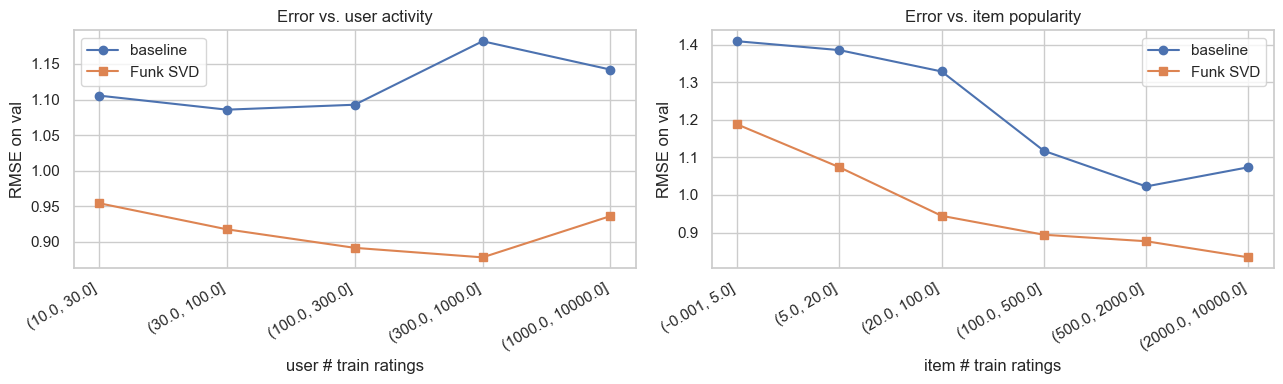

By user activity:
         user_bin     n  rmse_baseline  rmse_funk  funk_minus_baseline
     (10.0, 30.0]  9468       1.105515   0.954384            -0.151131
    (30.0, 100.0] 35844       1.085761   0.917706            -0.168056
   (100.0, 300.0] 66704       1.092702   0.891686            -0.201016
  (300.0, 1000.0] 48817       1.181910   0.878308            -0.303602
(1000.0, 10000.0]  1202       1.142053   0.936300            -0.205752

By item popularity:
         item_bin     n  rmse_baseline  rmse_funk  funk_minus_baseline
    (-0.001, 5.0]   402       1.408865   1.187824            -0.221041
      (5.0, 20.0]  2415       1.385250   1.073765            -0.311484
    (20.0, 100.0] 20530       1.328438   0.944518            -0.383920
   (100.0, 500.0] 80054       1.117377   0.894180            -0.223197
  (500.0, 2000.0] 55840       1.022657   0.876938            -0.145719
(2000.0, 10000.0]  2794       1.073687   0.834029            -0.239657


In [16]:
user_bins = [0, 10, 30, 100, 300, 1000, 10000]
item_bins = [0, 5, 20, 100, 500, 2000, 10000]
val_diag["user_bin"] = pd.cut(val_diag["user_n_train"], bins=user_bins, right=True, include_lowest=True)
val_diag["item_bin"] = pd.cut(val_diag["item_n_train"], bins=item_bins, right=True, include_lowest=True)

def bin_rmse(df: pd.DataFrame, bin_col: str) -> pd.DataFrame:
    g = df.groupby(bin_col, observed=True)
    out = pd.DataFrame({
        "n": g.size(),
        "rmse_baseline": np.sqrt(g["sq_err_global"].mean()),
        "rmse_funk":     np.sqrt(g["sq_err_funk"].mean()),
    })
    out["funk_minus_baseline"] = out["rmse_funk"] - out["rmse_baseline"]
    return out.reset_index()

user_bin_summary = bin_rmse(val_diag, "user_bin")
item_bin_summary = bin_rmse(val_diag, "item_bin")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(len(user_bin_summary)), user_bin_summary["rmse_baseline"], marker="o", label="baseline")
axes[0].plot(range(len(user_bin_summary)), user_bin_summary["rmse_funk"], marker="s", label="Funk SVD")
axes[0].set_xticks(range(len(user_bin_summary)))
axes[0].set_xticklabels([str(b) for b in user_bin_summary["user_bin"]], rotation=30, ha="right")
axes[0].set_xlabel("user # train ratings")
axes[0].set_ylabel("RMSE on val")
axes[0].set_title("Error vs. user activity")
axes[0].legend()

axes[1].plot(range(len(item_bin_summary)), item_bin_summary["rmse_baseline"], marker="o", label="baseline")
axes[1].plot(range(len(item_bin_summary)), item_bin_summary["rmse_funk"], marker="s", label="Funk SVD")
axes[1].set_xticks(range(len(item_bin_summary)))
axes[1].set_xticklabels([str(b) for b in item_bin_summary["item_bin"]], rotation=30, ha="right")
axes[1].set_xlabel("item # train ratings")
axes[1].set_ylabel("RMSE on val")
axes[1].set_title("Error vs. item popularity")
axes[1].legend()
plt.tight_layout()
plt.show()

print("By user activity:");  print(user_bin_summary.to_string(index=False))
print("\nBy item popularity:"); print(item_bin_summary.to_string(index=False))

**Here we can see that**:
- Funk SVD tends to make the biggest improvement in RSME on users with between 300 and 1000 ratings
- Error also shrinks when items have more ratings - perhaps since there is a stronger signal of the item to recommend

### 6.3 Error by true rating (extreme ratings)

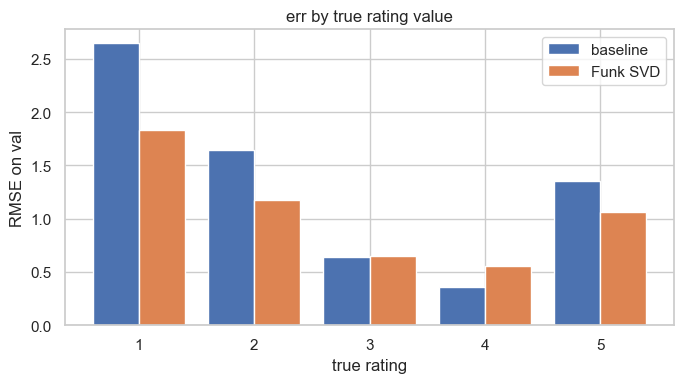

 rating     n  rmse_baseline  rmse_funk
      1  9826       2.644174   1.830751
      2 18579       1.644174   1.174138
      3 44671       0.644174   0.645650
      4 57114       0.355826   0.552341
      5 31845       1.355826   1.062762


In [17]:
by_rating = (val_diag.groupby("rating")
             .agg(n=("rating", "size"),
                  rmse_baseline=("sq_err_global", lambda x: float(np.sqrt(x.mean()))),
                  rmse_funk=("sq_err_funk", lambda x: float(np.sqrt(x.mean()))))
             .reset_index())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(by_rating))
ax.bar(x - 0.2, by_rating["rmse_baseline"], width=0.4, label="baseline")
ax.bar(x + 0.2, by_rating["rmse_funk"],     width=0.4, label="Funk SVD")
ax.set_xticks(x)
ax.set_xticklabels(by_rating["rating"])
ax.set_xlabel("true rating")
ax.set_ylabel("RMSE on val")
ax.set_title("err by true rating value")
ax.legend()
plt.tight_layout()
plt.show()

print(by_rating.to_string(index=False))

### 6.4 Discussion

**Funk SVD vs. baseline.** The bias + latent-factor model wins by a wide
  margin on warm rows but honestly makes no improvement on cold-start items
  (because there is no item information to use).





**Where most of the error is from.** The RSME bins we collected earlier show that error is
  worst on (1) low-popularity items and (2) extreme true ratings (1 and
  5). I think that is because since both methods regress predictions toward the global mean.
  Low-activity users contribute proportionally make up fewer rows.



**What I would do if I had more time**:
- I would try a lot more hyperparameter tuning in earlier steps
- I would try to eliminate temporal biases (since test ratings can drift away from our training ratings)

## 7. Final submission

Funk SVD had significantly better validation RSME, so now we want to refit it on the full `train.csv`. 
Our goal is now to just get the best performance possible, and then predict on our test pairs.

In [19]:
print(f"Funk SVD wins on validation ({best_funk_val_rmse:.4f} vs {global_mean_val_rmse:.4f}). "
        f"Refitting on full train.csv.")
final_model = FunkSVD(
    n_factors=int(best_cfg["K"]),
    lr=0.005,
    reg=float(best_cfg["reg"]),
    n_epochs=int(best_cfg["best_epoch"]),
    random_state=RNG_SEED,
).fit(train_df, val=None, verbose=True)
submission = final_model.predict(test_pairs_df)
final_choice = (f"FunkSVD(K={int(best_cfg['K'])}, reg={best_cfg['reg']}, "
                f"epoch={int(best_cfg['best_epoch'])})")

# Sanity checks before writing
assert set(submission.columns) == {"user_id", "item_id", "predicted_rating"}, submission.columns
assert len(submission) == len(test_pairs_df), (len(submission), len(test_pairs_df))
assert submission["predicted_rating"].notna().all(), "NaN predictions"
assert ((submission["predicted_rating"] >= RATING_MIN) &
        (submission["predicted_rating"] <= RATING_MAX)).all(), "out-of-range predictions"
# Every test pair appears exactly once
key_counts = submission.groupby(["user_id", "item_id"]).size()
assert (key_counts == 1).all(), "duplicate (user_id, item_id) rows"

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nWrote {len(submission):,} predictions to {SUBMISSION_PATH} (model: {final_choice}).")
print(f"Prediction stats — mean={submission['predicted_rating'].mean():.4f}, "
      f"std={submission['predicted_rating'].std():.4f}, "
      f"min={submission['predicted_rating'].min():.4f}, "
      f"max={submission['predicted_rating'].max():.4f}")
submission.head()

Funk SVD wins on validation (0.8976 vs 1.1199). Refitting on full train.csv.
epoch  1/15  train=0.9328  (5.5s)
epoch  2/15  train=0.9127  (5.6s)
epoch  3/15  train=0.9041  (5.6s)
epoch  4/15  train=0.8989  (5.5s)
epoch  5/15  train=0.8951  (5.5s)
epoch  6/15  train=0.8913  (5.5s)
epoch  7/15  train=0.8869  (5.5s)
epoch  8/15  train=0.8816  (5.5s)
epoch  9/15  train=0.8751  (5.4s)
epoch 10/15  train=0.8679  (5.5s)
epoch 11/15  train=0.8605  (5.4s)
epoch 12/15  train=0.8530  (5.4s)
epoch 13/15  train=0.8455  (5.4s)
epoch 14/15  train=0.8382  (5.5s)
epoch 15/15  train=0.8310  (5.4s)

Wrote 202,451 predictions to submission.csv (model: FunkSVD(K=20, reg=0.02, epoch=15)).
Prediction stats — mean=3.4848, std=0.6899, min=1.0000, max=5.0000


,user_id,item_id,predicted_rating
0,1,1,4.404995
1,1,48,3.220209
2,1,588,4.215470
3,1,595,4.122298
4,1,745,4.651976
